# FEM vs Pyramid and 2D MBIR on Synthetic Single-Image Data

This notebook applies the 3D physics-projected FEM-style inversion used in the FEM inversion notebooks to the synthetic single-image dataset from `mbir_and_pyramid.ipynb`.

The comparison is done on a downsampled proxy of the original synthetic problem so the 3D inversion remains tractable. We compare:

1. Pyramid 2D reconstruction
2. LiberTEM-holo 2D MBIR reconstruction
3. 3D FEM / physics-projected inversion from a single phase image

Because this dataset is synthetic, we can also compare all three against the known ground truth.

In [1]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.1'

import jax
jax.config.update('jax_enable_x64', True)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from pyramid.fielddata import VectorData
from pyramid.projector import SimpleProjector
from pyramid.phasemapper import PhaseMapperRDFC
from pyramid.phasemap import PhaseMap
from pyramid.kernel import Kernel
from pyramid.utils.convenience import reconstruction_2d_from_phasemap

from libertem_holo.base.shapes import create_mag_dist_homog, disc
from libertem_holo.base.mbir import add_units_to_inputs, forward_model_2d, lcurve_sweep_vmap, make_quantity, reconstruct_2d, support_center_yx
from libertem_holo.base.mbir import invert_magnetization, NeuralMagCritic
from libertem_holo.base.mbir.forward import forward_phase_from_density_and_magnetization

%matplotlib widget

/Users/landers/.conda/envs/holography_error/lib/python3.14/site-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda13_plugin version 0.9.1 is installed, but it is not compatible with the installed jaxlib version 0.9.0, so it will not be used.
  warnings.warn(


In [2]:
def downsample_2d(arr, factor):
    arr = np.asarray(arr)
    ny, nx = arr.shape
    return arr.reshape(ny // factor, factor, nx // factor, factor).mean(axis=(1, 3))

def downsample_3d(arr, factor):
    arr = np.asarray(arr)
    nz, ny, nx = arr.shape
    return arr.reshape(nz // factor, factor, ny // factor, factor, nx // factor, factor).mean(axis=(1, 3, 5))

def downsample_4d_zyxc(arr, factor):
    arr = np.asarray(arr)
    nz, ny, nx, nc = arr.shape
    return arr.reshape(nz // factor, factor, ny // factor, factor, nx // factor, factor, nc).mean(axis=(1, 3, 5))

def centered_slab_rho(mask_2d, thickness_px, nz):
    mask_2d = np.asarray(mask_2d, dtype=np.float32)
    z0 = 0.5 * (nz - thickness_px)
    z1 = z0 + thickness_px
    z_lo = np.arange(nz, dtype=np.float32)[:, None, None]
    z_hi = z_lo + 1.0
    fill = np.clip(np.minimum(z_hi, z1) - np.maximum(z_lo, z0), 0.0, 1.0)
    return fill * mask_2d[None, :, :]

def projected_from_volume(rho_zyx, m_zyxc):
    return np.sum(np.asarray(rho_zyx)[..., None] * np.asarray(m_zyxc), axis=0)[..., :2]

def normalize_field(m, rho, eps=1e-6):
    m = np.asarray(m, dtype=np.float32)
    rho = np.asarray(rho, dtype=np.float32)
    norms = np.linalg.norm(m, axis=-1, keepdims=True)
    safe = np.where(norms > eps, norms, 1.0)
    unit = m / safe
    fallback = np.zeros_like(unit)
    fallback[..., 0] = 1.0
    unit = np.where(norms > eps, unit, fallback)
    return np.where(rho[..., None] > 0.05, unit, 0.0).astype(np.float32)

def extrude_projected_init(rho, proj_2d):
    init = np.zeros(np.asarray(rho).shape + (3,), dtype=np.float32)
    init[..., 0] = np.asarray(proj_2d, dtype=np.float32)[None, ..., 0]
    init[..., 1] = np.asarray(proj_2d, dtype=np.float32)[None, ..., 1]
    return normalize_field(init, rho)

def phase_rms(pred, true):
    pred = np.asarray(pred, dtype=np.float64)
    true = np.asarray(true, dtype=np.float64)
    return float(np.sqrt(np.mean((pred - true) ** 2)))

def projected_rel_err(pred, true, mask=None, eps=1e-12):
    pred = np.asarray(pred, dtype=np.float64)
    true = np.asarray(true, dtype=np.float64)
    if mask is not None:
        pred = pred * mask[..., None]
        true = true * mask[..., None]
    return float(np.linalg.norm((pred - true).ravel()) / max(np.linalg.norm(true.ravel()), eps))

def make_neuralmag_backend(rho, pixel_size_nm):
    import neuralmag as nm  # type: ignore[import-not-found]

    mesh = nm.Mesh(rho.shape, (pixel_size_nm * 1e-9,) * 3)
    state = nm.State(mesh)
    state.rho = nm.CellFunction(state, tensor=state.tensor(np.asarray(rho, dtype=np.float32)))
    state.material.Ms = nm.CellFunction(state).fill(8e5)
    state.material.A = nm.CellFunction(state).fill(1.3e-11)
    state.m = nm.VectorCellFunction(state, tensor=state.tensor(np.zeros(rho.shape + (3,), dtype=np.float32)))
    nm.ExchangeField().register(state, 'exchange')
    nm.DemagField(p=1).register(state, 'demag')
    return NeuralMagCritic.from_state(state, terms=('exchange', 'demag'))

def show_projected_fields(rows, title):
    fig, axes = plt.subplots(len(rows), 3, figsize=(10, 2.6 * len(rows)), squeeze=False, constrained_layout=True)
    for row_idx, (label, field) in enumerate(rows):
        field = np.asarray(field)
        mx = field[..., 0]
        my = field[..., 1]
        mag = np.sqrt(mx ** 2 + my ** 2)
        vmax_mx = max(np.abs(mx).max(), 1e-12)
        vmax_my = max(np.abs(my).max(), 1e-12)
        im0 = axes[row_idx, 0].imshow(mx, cmap='RdBu_r', origin='lower', norm=TwoSlopeNorm(0, -vmax_mx, vmax_mx))
        im1 = axes[row_idx, 1].imshow(my, cmap='RdBu_r', origin='lower', norm=TwoSlopeNorm(0, -vmax_my, vmax_my))
        im2 = axes[row_idx, 2].imshow(mag, cmap='viridis', origin='lower')
        axes[row_idx, 0].set_ylabel(label)
        axes[row_idx, 0].set_title('Mx')
        axes[row_idx, 1].set_title('My')
        axes[row_idx, 2].set_title('|M|')
        for col in range(3):
            axes[row_idx, col].set_xticks([])
            axes[row_idx, col].set_yticks([])
        plt.colorbar(im0, ax=axes[row_idx, 0], fraction=0.046)
        plt.colorbar(im1, ax=axes[row_idx, 1], fraction=0.046)
        plt.colorbar(im2, ax=axes[row_idx, 2], fraction=0.046)
    fig.suptitle(title)
    plt.show()

def show_every_fourth_slices(m_true, m_recon, rho_ref, title):
    slice_indices = list(range(0, m_true.shape[0], 4))
    components = [(0, 'Mx'), (1, 'My'), (2, 'Mz')]
    fig, axes = plt.subplots(len(slice_indices), 6, figsize=(13, 2.0 * len(slice_indices)), squeeze=False)
    last_im = None
    for row_idx, z_idx in enumerate(slice_indices):
        support = rho_ref[z_idx] > 0.5
        for comp_offset, (comp_idx, comp_name) in enumerate(components):
            ax_t = axes[row_idx, comp_offset]
            ax_r = axes[row_idx, comp_offset + 3]
            ax_t.imshow(m_true[z_idx, :, :, comp_idx], vmin=-1, vmax=1, cmap='RdBu_r')
            last_im = ax_r.imshow(m_recon[z_idx, :, :, comp_idx], vmin=-1, vmax=1, cmap='RdBu_r')
            ax_t.contour(support, levels=[0.5], colors='k', linewidths=0.4)
            ax_r.contour(support, levels=[0.5], colors='k', linewidths=0.4)
            if row_idx == 0:
                ax_t.set_title(f'Truth {comp_name}', fontsize=9)
                ax_r.set_title(f'FEM {comp_name}', fontsize=9)
            ax_t.set_ylabel(f'z={z_idx}', fontsize=8)
            ax_t.set_xticks([]); ax_t.set_yticks([])
            ax_r.set_xticks([]); ax_r.set_yticks([])

    plt.suptitle(title, y=1.0)
    plt.tight_layout()
    plt.show()

In [3]:
N = 128
dim = (N, N, N)
center = (N // 2, N // 2, N // 2)
downsample = 4
N_ds = N // downsample

quantity_inputs = add_units_to_inputs(pixel_size=7.423, pixel_size_unit='nm', thickness=125.0, thickness_unit='nm')
pixel_size = quantity_inputs['pixel_size']
thickness_physical = quantity_inputs['thickness']

radius_physical = make_quantity(300.0, 'nm')
radius_pixels = int(round(float((radius_physical / pixel_size).value)))
height_pixels = int(round(float((thickness_physical / pixel_size).value)))

R = make_quantity(radius_pixels, 'pixel')
H = make_quantity(height_pixels, 'pixel')
mag_shape = disc(dim=dim, center=center, radius=R, height=H)
m_true_full = np.moveaxis(np.asarray(create_mag_dist_homog(mag_shape=mag_shape, phi=np.pi / 2), dtype=np.float32), 0, -1)
rho_true_full = (np.linalg.norm(m_true_full, axis=-1) > 0).astype(np.float32)

m_true_ds = normalize_field(downsample_4d_zyxc(m_true_full, downsample), downsample_3d(rho_true_full, downsample))
rho_true_ds = (downsample_3d(rho_true_full, downsample) > 0.25).astype(np.float32)
mask_ds = np.max(rho_true_ds, axis=0).astype(np.float32)

pixel_size_ds = make_quantity(float(pixel_size.value) * downsample, 'nm')
thickness_px_ds = height_pixels / downsample
rho_guess = centered_slab_rho(mask_ds, thickness_px_ds, nz=N_ds).astype(np.float32)
yx_center = support_center_yx(rho_guess)

# Generate the measurement using the FEM forward model evaluated directly at the
# downsampled scale. Downsampling a high-resolution phase instead causes an ~8x
# amplitude mismatch because the forward model integral scales with voxel size,
# making it impossible for the unit-norm FEM solver to match the observed phase.
phase_mag_ds = np.asarray(
    forward_phase_from_density_and_magnetization(
        rho=rho_true_ds,
        magnetization_3d=m_true_ds,
        pixel_size=pixel_size_ds,
        axis='z',
    ),
    dtype=np.float32,
)

proj_true_ds = projected_from_volume(rho_true_ds, m_true_ds)
print('Downsampled phase shape:', phase_mag_ds.shape)
print('Downsampled volume shape:', rho_guess.shape)
print('Downsampled center:', yx_center)
print('Phase max amplitude:', float(np.max(np.abs(phase_mag_ds))))

W0421 11:09:49.974403  800017 autotuner.cc:583] No reference output found even though buffer checking was requested while autotuning


Downsampled phase shape: (32, 32)
Downsampled volume shape: (32, 32, 32)
Downsampled center: (16, 16)
Phase max amplitude: 26.33847427368164


In [4]:
best_lam_pyr = 1e-4
pm = PhaseMap(a=float(pixel_size_ds.value), phase=np.asarray(phase_mag_ds), mask=mask_ds.astype(bool))
magdata_pyr, cost_pyr = reconstruction_2d_from_phasemap(pm, lam=best_lam_pyr, max_iter=5000, ramp_order=None, verbose=True)
u_pyr = magdata_pyr.field[0, 0, ...]
v_pyr = magdata_pyr.field[1, 0, ...]
proj_pyr = np.stack([u_pyr, v_pyr], axis=-1)
kern_pyr = Kernel(float(pixel_size_ds.value), phase_mag_ds.shape, geometry='disc')
mapper_pyr = PhaseMapperRDFC(kern_pyr)
field_pyr = np.zeros((3, 1) + phase_mag_ds.shape, dtype=np.float32)
field_pyr[0, 0] = u_pyr
field_pyr[1, 0] = v_pyr
pred_pyr = mapper_pyr(VectorData(float(pixel_size_ds.value), field_pyr)).phase

CG:   0%|          | 0/5000 [00:00<?, ?it/s]

In [5]:
mbir_inputs = add_units_to_inputs(phase=phase_mag_ds, pixel_size=float(pixel_size_ds.value))
phase_q = mbir_inputs['phase']
lambdas_mbir = np.logspace(-6, 1, num=12)
lc_mbir = lcurve_sweep_vmap(phase=phase_q, mask=mask_ds, pixel_size=pixel_size_ds, lambdas=lambdas_mbir, solver='newton_cg')
best_lam_mbir = lc_mbir.lambdas[lc_mbir.corner_index]
result_mbir = reconstruct_2d(phase=phase_q, pixel_size=pixel_size_ds, mask=mask_ds, lam=best_lam_mbir, solver='newton_cg')
proj_mbir = np.asarray(result_mbir.magnetization.value)
pred_mbir = np.asarray(forward_model_2d(result_mbir.magnetization, pixel_size_ds, ramp_coeffs=result_mbir.ramp_coeffs).value)

In [6]:
backend_fem = make_neuralmag_backend(rho_guess, float(pixel_size_ds.value))
init_fem = extrude_projected_init(rho_guess, proj_mbir)
result_fem = invert_magnetization(
    phase_mag_ds,
    rho_guess,
    backend_fem,
    pixel_size=pixel_size_ds,
    lambda_phys=0.0,  # physics term causes NaN at initialization; data-only is sufficient for single-view
    max_iter=300,
    lr=1e-3,
    init=init_fem,
    axis='z',
    projection_threshold=0.25,
    )
m_fem = np.asarray(result_fem.m_recon)
proj_fem = projected_from_volume(rho_guess, m_fem)
pred_fem = np.asarray(result_fem.phi_pred)

2026-04-21 11:10:05 NeuralMag:INFO [NeuralMag] Version 0.9.4
2026-04-21 11:10:05 NeuralMag:INFO [Mesh] 3D, 32 x 32 x 32 (size = 2.9692e-08 x 2.9692e-08 x 2.9692e-08)
2026-04-21 11:10:05 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-21 11:10:05 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-21 11:10:05 NeuralMag:INFO [NeuralMag] Set default dtype to 'float32'.
2026-04-21 11:10:05 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float32, backend = jax)
2026-04-21 11:10:05 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-21 11:10:05 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-21 11:10:05 NeuralMag:INFO [DemagField]: Set up demag tensor
W0421 11:10:09.939098  799995 autotuner.cc:583] No reference output found even though buffer checking was requested while autotuning
W0421 11:10:09.9405

In [7]:
rows = [
    ('Truth', phase_mag_ds, proj_true_ds),
    ('Pyramid', pred_pyr, proj_pyr),
    ('2D MBIR', pred_mbir, proj_mbir),
    ('FEM warm-start', pred_fem, proj_fem),
]
print(f"{'Method':<16} {'phase_rms':>12} {'proj_rel_err':>14}")
print('-' * 46)
for label, pred_phase, proj_field in rows[1:]:
    print(f"{label:<16} {phase_rms(pred_phase, phase_mag_ds):>12.6f} {projected_rel_err(proj_field, proj_true_ds, mask_ds):>14.6f}")

Method              phase_rms   proj_rel_err
----------------------------------------------
Pyramid              0.000000       0.000001
2D MBIR              0.000068       0.000228
FEM warm-start       0.000013       0.000150


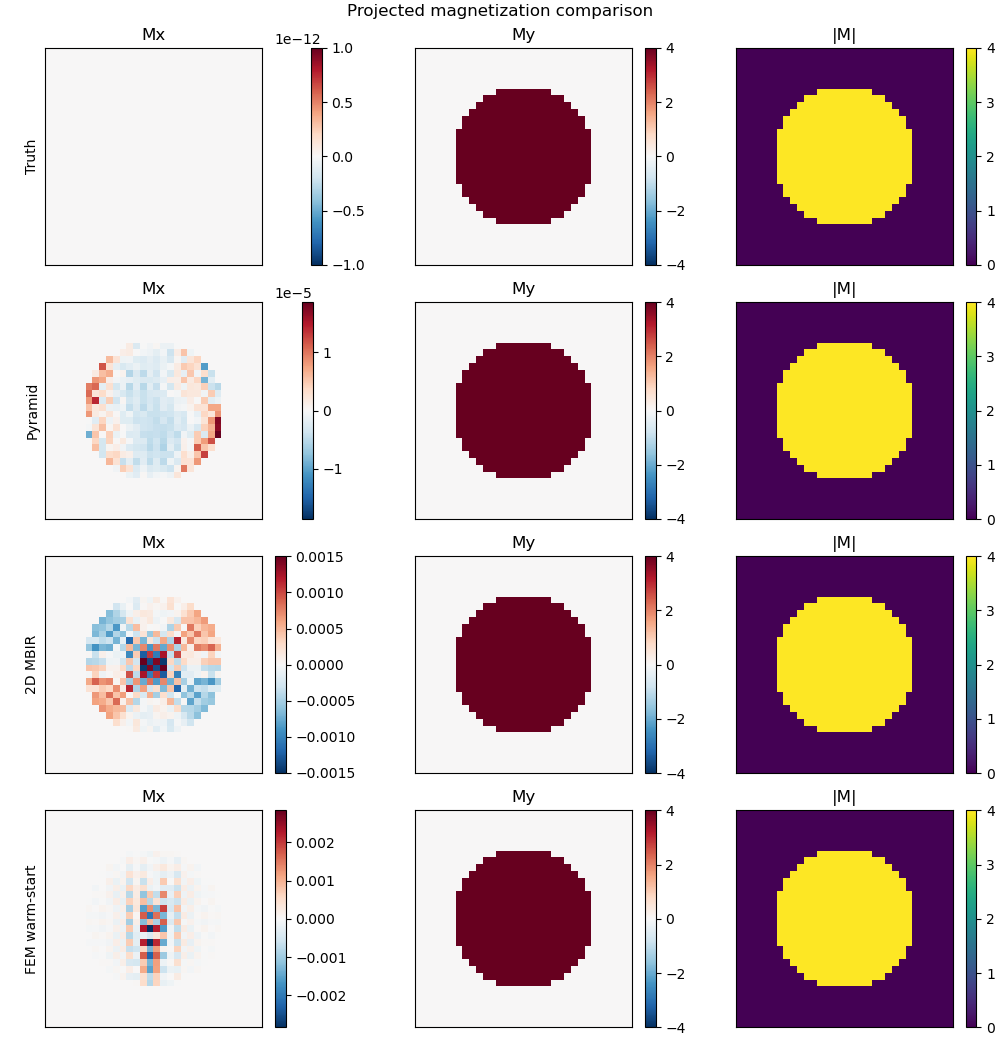

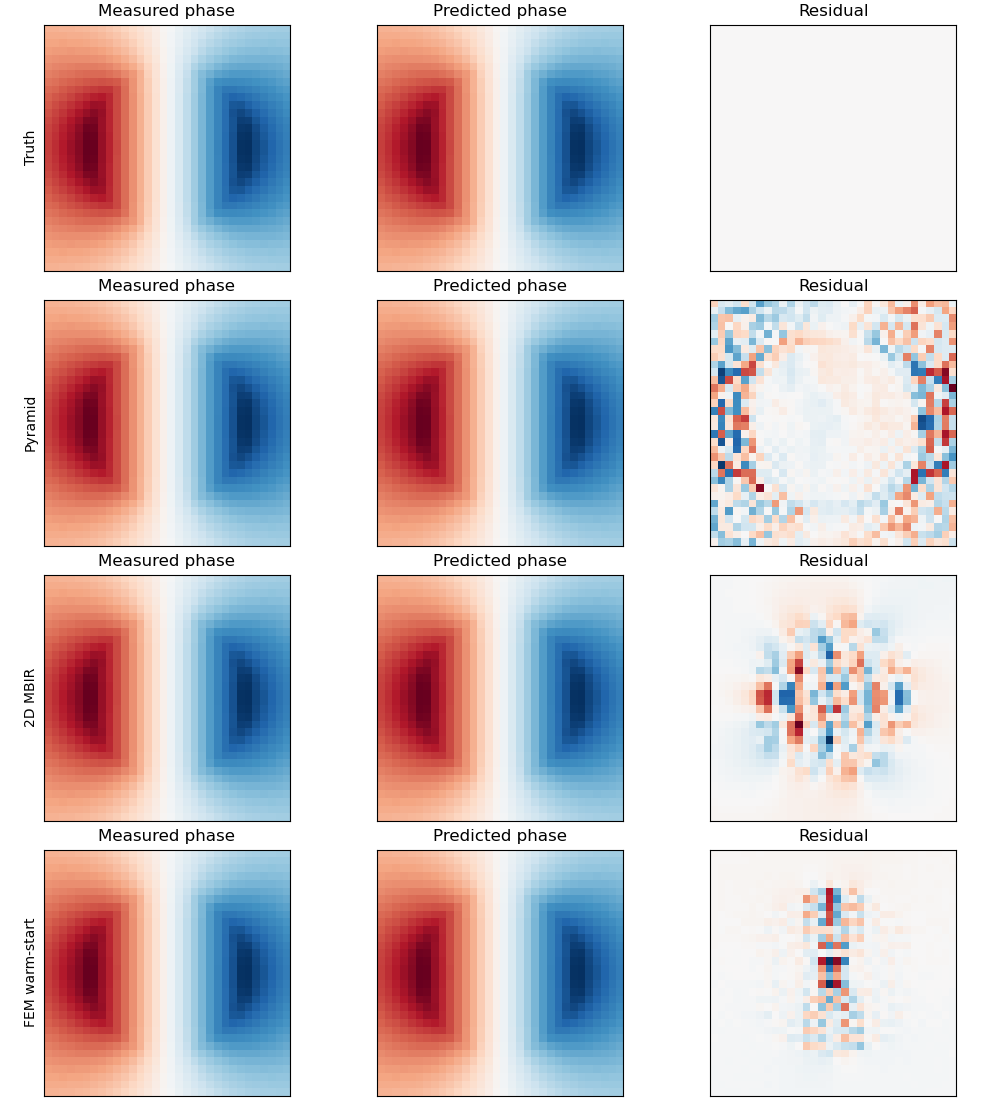

In [8]:
show_projected_fields([(entry[0], entry[2]) for entry in rows], 'Projected magnetization comparison')

fig, axes = plt.subplots(4, 3, figsize=(10, 11), constrained_layout=True)
for row_idx, row in enumerate(rows):
    label, pred_phase, proj_field = row
    del proj_field
    residual = np.asarray(pred_phase) - phase_mag_ds
    vmax_phase = max(np.max(np.abs(phase_mag_ds)), np.max(np.abs(pred_phase)), 1e-12)
    vmax_res = max(np.max(np.abs(residual)), 1e-12)
    im0 = axes[row_idx, 0].imshow(phase_mag_ds, cmap='RdBu_r', vmin=-vmax_phase, vmax=vmax_phase)
    im1 = axes[row_idx, 1].imshow(pred_phase, cmap='RdBu_r', vmin=-vmax_phase, vmax=vmax_phase)
    im2 = axes[row_idx, 2].imshow(residual, cmap='RdBu_r', vmin=-vmax_res, vmax=vmax_res)
    axes[row_idx, 0].set_ylabel(label)
    axes[row_idx, 0].set_title('Measured phase')
    axes[row_idx, 1].set_title('Predicted phase')
    axes[row_idx, 2].set_title('Residual')
    for col in range(3):
        axes[row_idx, col].set_xticks([])
        axes[row_idx, col].set_yticks([])
plt.show()

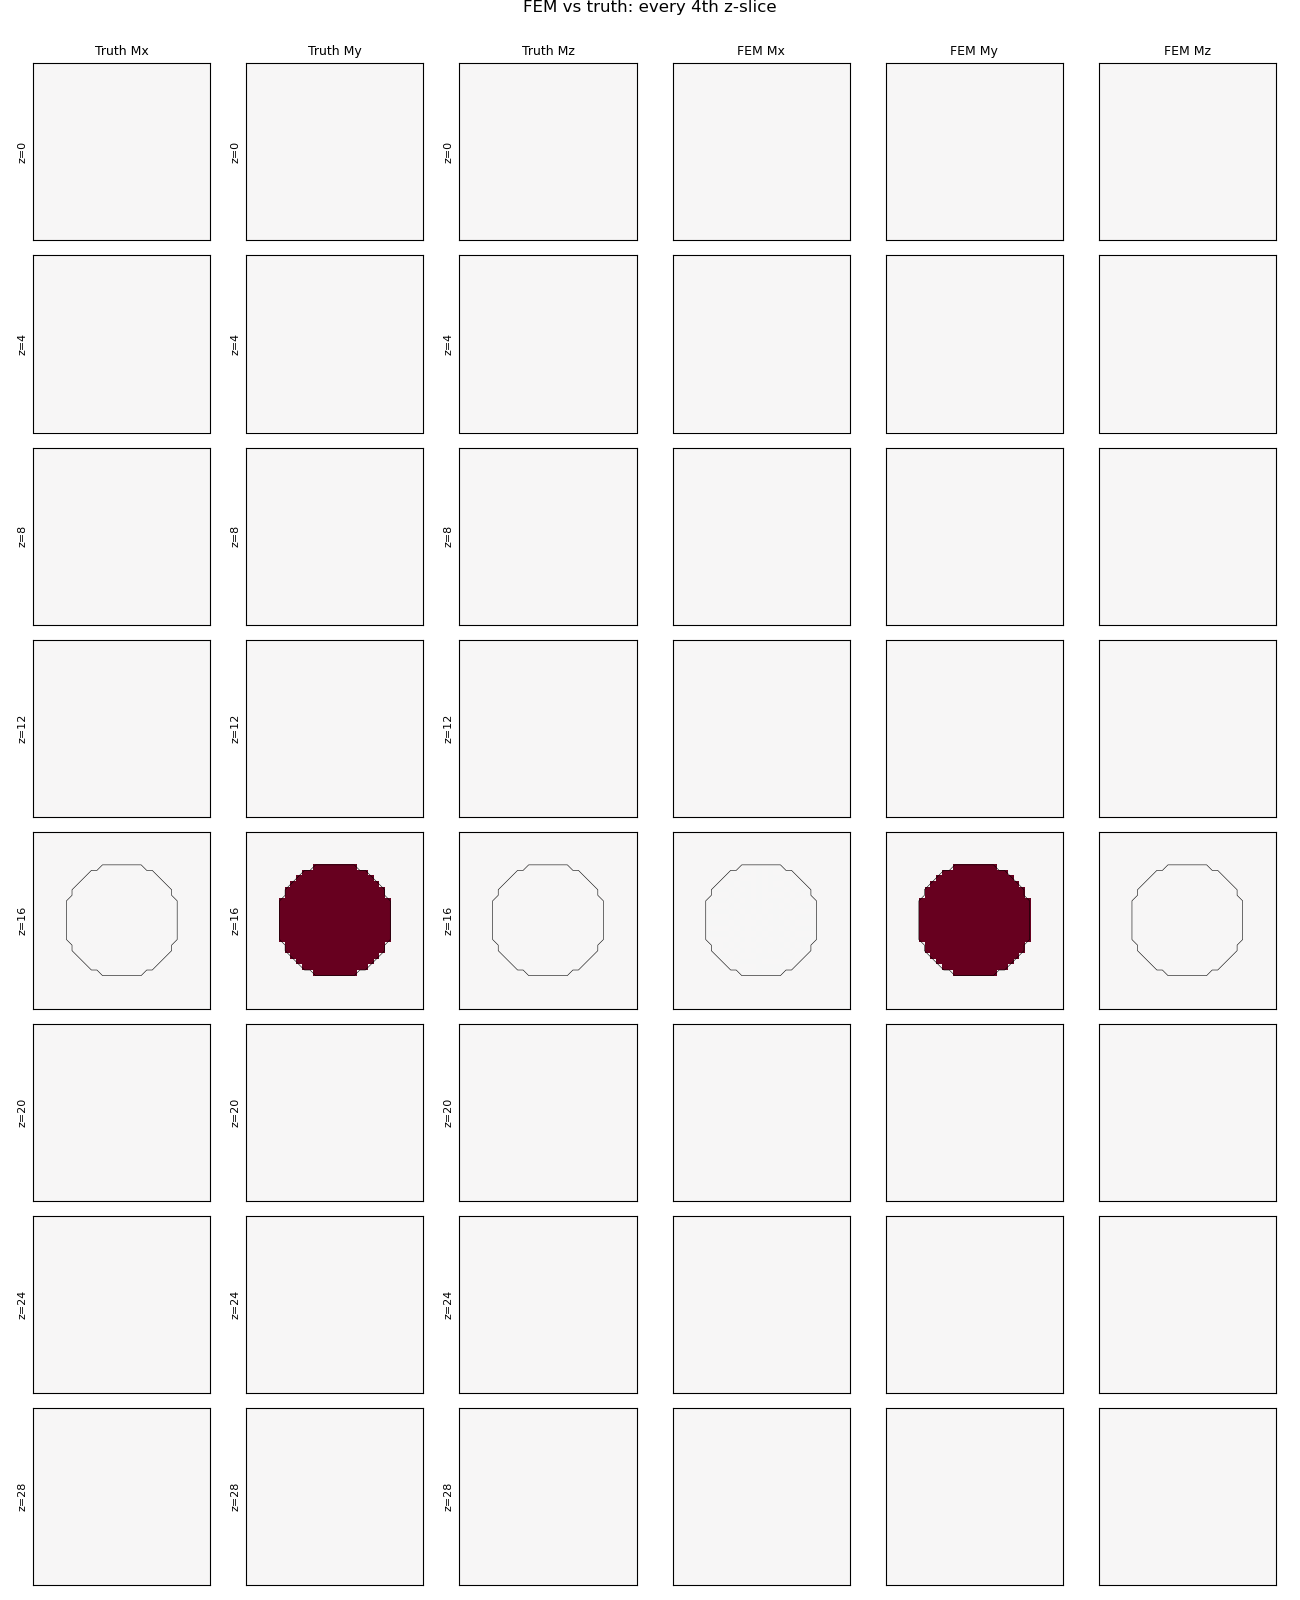

In [9]:
show_every_fourth_slices(m_true_ds, m_fem, rho_guess, 'FEM vs truth: every 4th z-slice')